# SSD failure-label exploratory data analysis

This notebook analyzes
`S_CDATOS_PSET2.S_CDATOS_PSET2_SILVER.SSD_FAILURE_LABELS` through the
Snowflake Spark connector.

The label relation has a different analytical grain from the annual SMART
tables: each row represents a labeled failure event. Its menu therefore covers
disk, model, failure date, and failure-hour distributions. Pairwise interaction
is expressed as co-occurrence counts rather than covariance between SMART
measurements.


## 0. Runtime, imports, and configuration

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyspark
import seaborn as sns

from snowflake_io import create_spark_session, read_snowflake_query

print("Python:", sys.executable)
print("PySpark:", pyspark.__version__)
print("Spark home:", os.environ.get("SPARK_HOME"))

spark = create_spark_session("ssd-failure-labels-cloud-eda")
spark.conf.set("spark.sql.debug.maxToStringFields", 100)

LABEL_TABLE = "S_CDATOS_PSET2.S_CDATOS_PSET2_SILVER.SSD_FAILURE_LABELS"
LABEL_SCHEMA = "S_CDATOS_PSET2_SILVER"
LABEL_VARIABLES = ["DISK_ID", "MODEL_CODE", "FAILURE_DATE", "FAILURE_AT"]
VARIABLE_MENU = pd.DataFrame({
    "NUMBER": range(1, len(LABEL_VARIABLES) + 1),
    "VARIABLE": LABEL_VARIABLES,
})

NULL_PATTERN_DISPLAY_LIMIT = 10_000
INTERACTION_DISPLAY_LIMIT = 200
EXPORT_DIR = Path("/opt/spark/notebooks/exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 500)


Python: /usr/bin/python3
PySpark: 4.0.4
Spark home: /opt/spark


26/09/29 20:01:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/29 20:01:51 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
def quote_identifier(value: str) -> str:
    if value not in LABEL_VARIABLES:
        raise ValueError(f"Unrecognized label variable: {value}")
    return '"' + value.replace('"', '""') + '"'


def snowflake_query(query: str):
    return read_snowflake_query(spark, query, schema=LABEL_SCHEMA)


def aggregate_to_pandas(query: str) -> pd.DataFrame:
    return snowflake_query(query).toPandas()


def show_variable_menu() -> None:
    display(VARIABLE_MENU)


def select_variable(prompt: str, *, excluded: set[str] | None = None) -> str:
    excluded = excluded or set()
    while True:
        raw_value = input(f"{prompt} [1-{len(LABEL_VARIABLES)}]: ").strip()
        try:
            number = int(raw_value)
        except ValueError:
            print("Enter an integer from the NUMBER column.")
            continue
        if not 1 <= number <= len(LABEL_VARIABLES):
            print(f"Enter a number between 1 and {len(LABEL_VARIABLES)}.")
            continue
        variable = LABEL_VARIABLES[number - 1]
        if variable in excluded:
            print(f"{variable} is already selected; choose another variable.")
            continue
        print(f"Selected {number} -> {variable}")
        return variable


def category_expression(variable: str) -> str:
    quote_identifier(variable)
    if variable == "FAILURE_AT":
        return "TO_VARCHAR(DATE_TRUNC('hour', FAILURE_AT))"
    if variable == "FAILURE_DATE":
        return "TO_VARCHAR(FAILURE_DATE)"
    if variable == "DISK_ID":
        return "TO_VARCHAR(DISK_ID)"
    return "MODEL_CODE"


def distribution_for(variable: str) -> pd.DataFrame:
    expression = category_expression(variable)
    return aggregate_to_pandas(f'''
        SELECT
            {expression} AS CATEGORY,
            COUNT(*) AS RECORD_COUNT,
            ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 6) AS RECORD_PERCENT
        FROM {LABEL_TABLE}
        WHERE {quote_identifier(variable)} IS NOT NULL
        GROUP BY 1
        ORDER BY RECORD_COUNT DESC, CATEGORY
    ''')


## 1. Menu-driven univariate distribution

Select one label variable. The next cell returns its complete aggregated
distribution table; the following cell plots its most informative categories.


In [3]:
show_variable_menu()
selected_label_variable = select_variable("Select the label variable")


,NUMBER,VARIABLE
0,1,DISK_ID
1,2,MODEL_CODE
2,3,FAILURE_DATE
3,4,FAILURE_AT


Selected 2 -> MODEL_CODE


In [4]:
selected_distribution = distribution_for(selected_label_variable)
display(selected_distribution)


26/09/29 20:02:16 WARN NoOpFileCacheManager: Cache is not available. Caching will be disabled. Set the HOME, SF_TEMPORARY_CREDENTIAL_CACHE_DIR, or net.snowflake.jdbc.temporaryCredentialCacheDir to enable caching.
26/09/29 20:02:18 ERROR RestRequest: Stop retrying since elapsed time due to network issues has reached timeout. Elapsed: 1,182 ms, timeout: 1,000 ms
26/09/29 20:02:18 ERROR RestRequest: Stop retrying since elapsed time due to network issues has reached timeout. Elapsed: 1,182 ms, timeout: 1,000 ms
26/09/29 20:02:18 ERROR RestRequest: Returning null response. Cause: java.net.UnknownHostException: metadata.google.internal, request: GET http://metadata.google.internal HTTP/1.1
26/09/29 20:02:18 ERROR RestRequest: Returning null response. Cause: java.net.UnknownHostException: metadata.google.internal, request: GET http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/email HTTP/1.1
26/09/29 20:02:18 ERROR RestRequest: Stop retrying since elapsed tim

,CATEGORY,RECORD_COUNT,RECORD_PERCENT
0,MC1,10510,64.458755
1,MB1,1807,11.082490
2,MA1,1370,8.402331
3,MC2,1131,6.936523
4,MA2,883,5.415517
5,MB2,604,3.704385


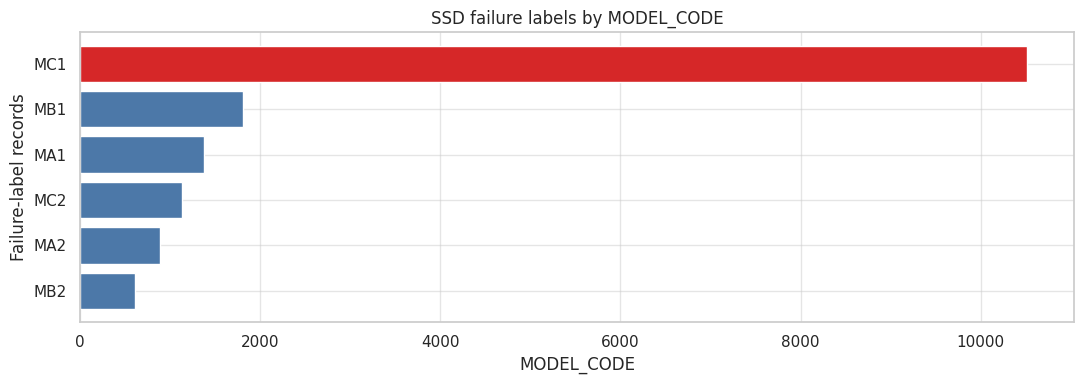

In [5]:
plot_distribution = selected_distribution.head(40).copy()
if selected_label_variable in {"FAILURE_DATE", "FAILURE_AT"}:
    plot_distribution = plot_distribution.sort_values("CATEGORY")
    _, axis = plt.subplots(figsize=(12, 5))
    axis.plot(
        plot_distribution["CATEGORY"],
        plot_distribution["RECORD_COUNT"].astype(float),
        marker="o",
    )
    axis.tick_params(axis="x", rotation=70)
else:
    plot_distribution = plot_distribution.sort_values("RECORD_COUNT")
    _, axis = plt.subplots(figsize=(11, max(4, 0.3 * len(plot_distribution))))
    colors = [
        "#d62728" if selected_label_variable == "MODEL_CODE" and str(value).upper() == "MC1"
        else "#4c78a8"
        for value in plot_distribution["CATEGORY"]
    ]
    axis.barh(
        plot_distribution["CATEGORY"].astype(str),
        plot_distribution["RECORD_COUNT"].astype(float),
        color=colors,
    )
axis.set_title(f"SSD failure labels by {selected_label_variable}")
axis.set_xlabel(selected_label_variable)
axis.set_ylabel("Failure-label records")
plt.tight_layout()
plt.show()


## 2. Interaction between two selected label variables

Select two distinct variables. Snowflake groups the observed pairs and returns
their record counts and share of all non-null selected pairs. This is a
co-occurrence analysis; `DISK_ID` is an identifier, so treating it as a
continuous measurement for covariance would not be meaningful.


In [6]:
show_variable_menu()
selected_interaction_a = select_variable("Select the first label variable")
selected_interaction_b = select_variable(
    "Select the second label variable",
    excluded={selected_interaction_a},
)


,NUMBER,VARIABLE
0,1,DISK_ID
1,2,MODEL_CODE
2,3,FAILURE_DATE
3,4,FAILURE_AT


Selected 1 -> DISK_ID
Selected 2 -> MODEL_CODE


In [8]:
expression_a = category_expression(selected_interaction_a)
expression_b = category_expression(selected_interaction_b)
label_interactions = aggregate_to_pandas(f'''
    SELECT
        {expression_a} AS VARIABLE_A_VALUE,
        {expression_b} AS VARIABLE_B_VALUE,
        COUNT(*) AS RECORD_COUNT,
        ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 6) AS RECORD_PERCENT
    FROM {LABEL_TABLE}
    WHERE {quote_identifier(selected_interaction_a)} IS NOT NULL
      AND {quote_identifier(selected_interaction_b)} IS NOT NULL
    GROUP BY 1, 2
    ORDER BY RECORD_COUNT DESC, VARIABLE_A_VALUE, VARIABLE_B_VALUE
    LIMIT {INTERACTION_DISPLAY_LIMIT}
''')
label_interactions


,VARIABLE_A_VALUE,VARIABLE_B_VALUE,RECORD_COUNT,RECORD_PERCENT
0,100001,MC1,1,0.006133
1,10001,MC2,1,0.006133
2,100016,MC1,1,0.006133
3,100021,MC1,1,0.006133
4,100054,MC1,1,0.006133
5,10008,MC2,1,0.006133
6,10009,MA1,1,0.006133
7,100093,MC1,1,0.006133
8,1001,MC1,1,0.006133
9,100128,MC1,1,0.006133


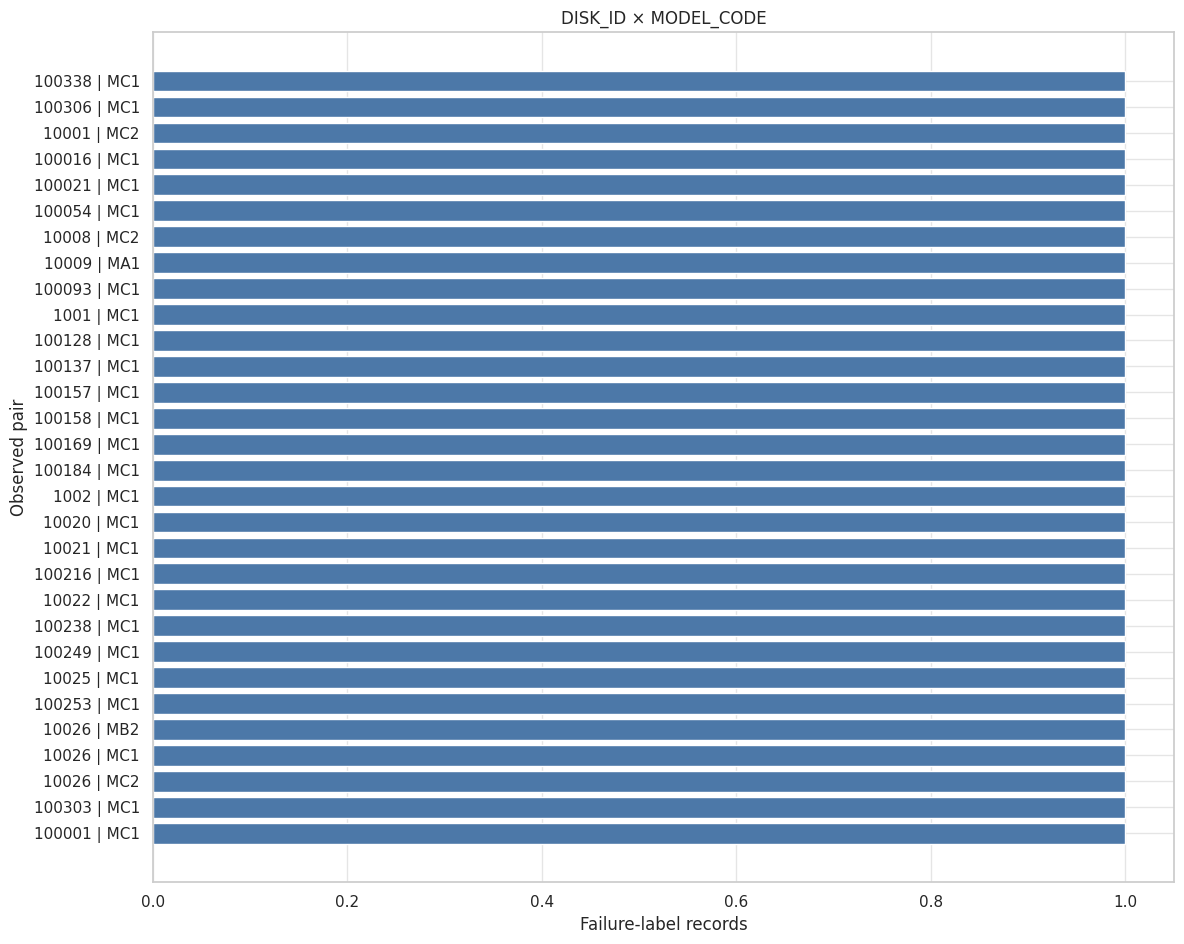

In [9]:
interaction_plot = label_interactions.head(30).copy()
interaction_plot["PAIR"] = (
    interaction_plot["VARIABLE_A_VALUE"].astype(str)
    + " | "
    + interaction_plot["VARIABLE_B_VALUE"].astype(str)
)
interaction_plot = interaction_plot.sort_values("RECORD_COUNT")

_, axis = plt.subplots(figsize=(12, max(5, 0.32 * len(interaction_plot))))
axis.barh(
    interaction_plot["PAIR"],
    interaction_plot["RECORD_COUNT"].astype(float),
    color="#4c78a8",
)
axis.set_title(f"{selected_interaction_a} × {selected_interaction_b}")
axis.set_xlabel("Failure-label records")
axis.set_ylabel("Observed pair")
plt.tight_layout()
plt.show()


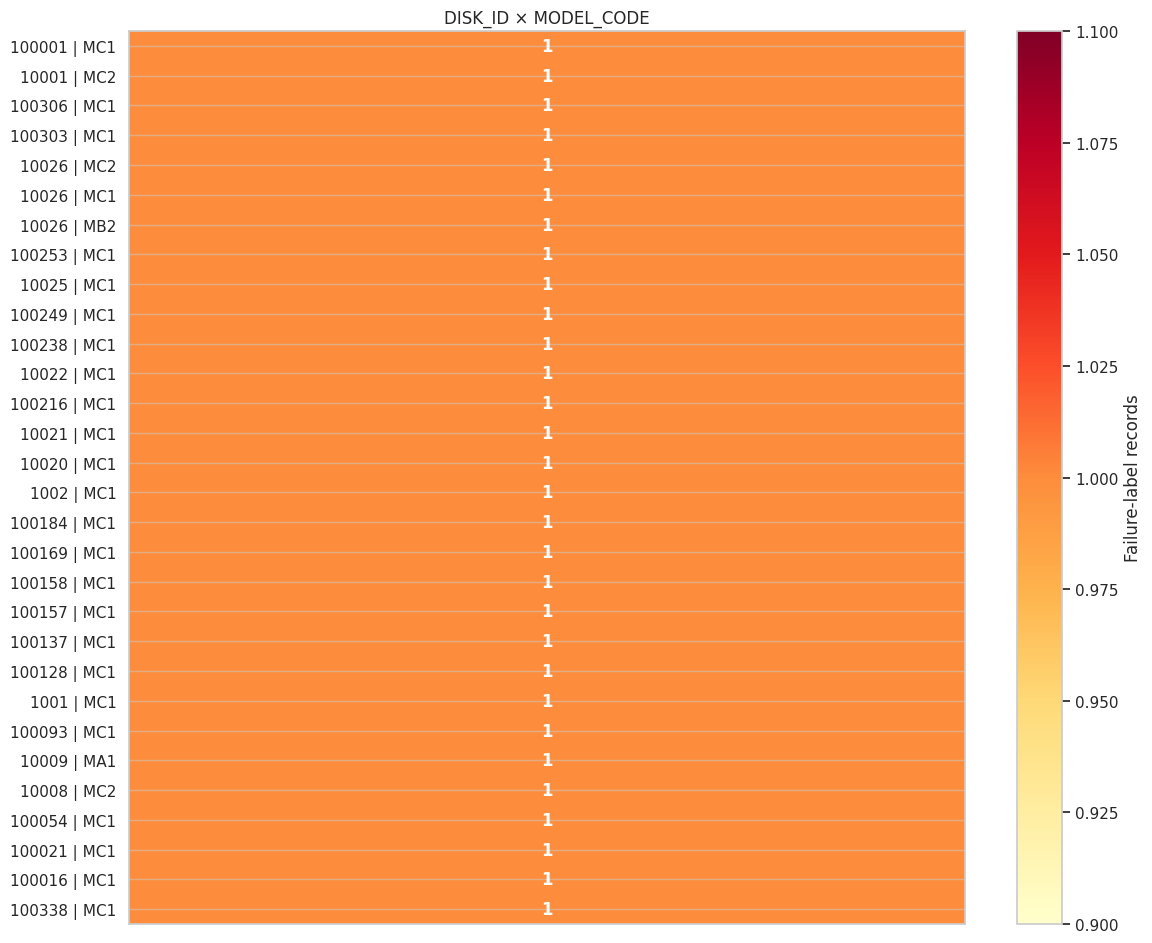

In [12]:
#? HEATMAP para mejor visualizacion
import numpy as np


interaction_plot = label_interactions.head(30).copy()
interaction_plot["PAIR"] = (
    interaction_plot["VARIABLE_A_VALUE"].astype(str)
    + " | "
    + interaction_plot["VARIABLE_B_VALUE"].astype(str)
)

# Sort by RECORD_COUNT for better visualization
interaction_plot = interaction_plot.sort_values("RECORD_COUNT", ascending=False)

# Create the heatmap
fig, ax = plt.subplots(figsize=(12, max(5, 0.32 * len(interaction_plot))))

# Create a heatmap using imshow with a single column
heatmap_data = interaction_plot["RECORD_COUNT"].values.reshape(-1, 1).astype(float)
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd')  # You can choose any colormap

# Customize the heatmap
ax.set_yticks(np.arange(len(interaction_plot)))
ax.set_yticklabels(interaction_plot["PAIR"])
ax.set_xticks([])  # Hide x-ticks since we only have one column
ax.set_title(f"{selected_interaction_a} × {selected_interaction_b}")

# Add colorbar to show the scale
cbar = ax.figure.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label('Failure-label records')

# Add text annotations with count values inside each cell
for i in range(len(interaction_plot)):
    count = interaction_plot.iloc[i]["RECORD_COUNT"]
    text_color = 'white' if count > heatmap_data.max() * 0.7 else 'black'  # Adjust text color for visibility
    ax.text(0, i, f'{count:,}', ha='center', va='center', color=text_color, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Null-pattern analysis and CSV exports

The first cell ranks nullable business columns and exports the ranking. The
second cell groups exact simultaneous-null combinations and exports those
patterns independently.


In [13]:
null_count_expressions = [
    f'COUNT_IF({quote_identifier(column)} IS NULL) AS "M{index}"'
    for index, column in enumerate(LABEL_VARIABLES)
]
null_count_row = aggregate_to_pandas(
    "SELECT COUNT(*) AS TOTAL_ROWS,\n" + ",\n".join(null_count_expressions)
    + f"\nFROM {LABEL_TABLE}"
).iloc[0]

total_rows = int(null_count_row["TOTAL_ROWS"])
null_column_summary = pd.DataFrame.from_records([
    {
        "VARIABLE": column,
        "NULL_ROWS": int(null_count_row[f"M{index}"]),
        "NULL_PERCENT": 100 * int(null_count_row[f"M{index}"]) / total_rows,
    }
    for index, column in enumerate(LABEL_VARIABLES)
    if int(null_count_row[f"M{index}"]) > 0
], columns=["VARIABLE", "NULL_ROWS", "NULL_PERCENT"]).sort_values(
    ["NULL_ROWS", "VARIABLE"], ascending=[False, True]
).reset_index(drop=True)

nullable_columns = null_column_summary["VARIABLE"].tolist()
null_column_export = EXPORT_DIR / "ssd_failure_labels_null_counts_by_column.csv"
null_column_summary.to_csv(null_column_export, index=False)
print(f"Exported null-column ranking to {null_column_export}")

null_column_summary


Exported null-column ranking to /opt/spark/notebooks/exports/ssd_failure_labels_null_counts_by_column.csv


,VARIABLE,NULL_ROWS,NULL_PERCENT


In [14]:
if not nullable_columns:
    null_pattern_details = pd.DataFrame([{
        "NULL_COLUMN_COUNT": 0,
        "NULL_COLUMNS": "[]",
        "RECORD_COUNT": total_rows,
    }])
else:
    null_array_items = [
        f"IFF({quote_identifier(column)} IS NULL, '{column}', NULL)"
        for column in nullable_columns
    ]
    null_pattern_details = aggregate_to_pandas(f'''
        WITH row_patterns AS (
            SELECT ARRAY_CONSTRUCT_COMPACT(
                {', '.join(null_array_items)}
            ) AS NULL_COLUMN_ARRAY
            FROM {LABEL_TABLE}
        ),
        pattern_counts AS (
            SELECT
                ARRAY_SIZE(NULL_COLUMN_ARRAY) AS NULL_COLUMN_COUNT,
                TO_JSON(NULL_COLUMN_ARRAY) AS NULL_COLUMNS,
                COUNT(*) AS RECORD_COUNT
            FROM row_patterns
            GROUP BY 1, 2
        )
        SELECT *
        FROM pattern_counts
        ORDER BY NULL_COLUMN_COUNT DESC, RECORD_COUNT DESC, NULL_COLUMNS
        LIMIT {NULL_PATTERN_DISPLAY_LIMIT}
    ''')


null_pattern_export = EXPORT_DIR / "ssd_failure_labels_null_combinations.csv"
null_pattern_details.to_csv(null_pattern_export, index=False)
print(f"Exported null combinations to {null_pattern_export}")


null_pattern_details

Exported null combinations to /opt/spark/notebooks/exports/ssd_failure_labels_null_combinations.csv


,NULL_COLUMN_COUNT,NULL_COLUMNS,RECORD_COUNT
0,0,[],16305


## 4. Disk, model, and failure-date distributions

### 4.1 Disk failure-label table

In [15]:
disk_distribution = aggregate_to_pandas(f'''
    SELECT
        DISK_ID,
        COUNT(*) AS FAILURE_LABEL_COUNT,
        COUNT(DISTINCT MODEL_CODE) AS MODEL_COUNT,
        MIN(FAILURE_AT) AS FIRST_FAILURE_AT,
        MAX(FAILURE_AT) AS LAST_FAILURE_AT
    FROM {LABEL_TABLE}
    GROUP BY DISK_ID
    ORDER BY FAILURE_LABEL_COUNT DESC, DISK_ID
    LIMIT 100
''')


disk_distribution


,DISK_ID,FAILURE_LABEL_COUNT,MODEL_COUNT,FIRST_FAILURE_AT,LAST_FAILURE_AT
0,3824,4,4,2018-08-29 03:27:58,2019-12-17 09:00:52
1,2519,3,3,2018-08-11 03:28:54,2019-08-25 22:01:12
2,3022,3,3,2018-07-15 11:17:35,2019-03-22 10:25:30
3,3462,3,3,2018-08-17 08:55:15,2019-06-26 20:25:31
4,4915,3,3,2018-08-11 03:15:11,2019-07-06 14:54:30
5,9055,3,3,2018-05-24 21:20:35,2018-07-17 03:26:27
6,10026,3,3,2018-08-24 10:34:09,2019-08-12 11:46:04
7,10681,3,3,2018-08-11 03:14:35,2019-10-05 07:18:04
8,11104,3,3,2019-01-17 03:08:11,2019-10-02 21:59:47
9,18756,3,3,2019-01-27 03:10:40,2019-08-14 21:47:14


### 4.2 Model table with MC1 emphasis

In [16]:
model_distribution = aggregate_to_pandas(f'''
    SELECT
        MODEL_CODE,
        IFF(UPPER(MODEL_CODE) = 'MC1', 'TARGET_MC1', 'OTHER_MODEL') AS MODEL_GROUP,
        COUNT(*) AS FAILURE_LABEL_COUNT,
        COUNT(DISTINCT DISK_ID) AS FAILED_DISK_COUNT,
        MIN(FAILURE_DATE) AS FIRST_FAILURE_DATE,
        MAX(FAILURE_DATE) AS LAST_FAILURE_DATE,
        ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 6) AS RECORD_PERCENT
    FROM {LABEL_TABLE}
    GROUP BY MODEL_CODE
    ORDER BY IFF(UPPER(MODEL_CODE) = 'MC1', 0, 1), FAILURE_LABEL_COUNT DESC
''')

model_distribution


,MODEL_CODE,MODEL_GROUP,FAILURE_LABEL_COUNT,FAILED_DISK_COUNT,FIRST_FAILURE_DATE,LAST_FAILURE_DATE,RECORD_PERCENT
0,MC1,TARGET_MC1,10510,10510,2018-01-03,2019-12-31,64.458755
1,MB1,OTHER_MODEL,1807,1807,2018-01-15,2019-12-31,11.082490
2,MA1,OTHER_MODEL,1370,1370,2018-01-03,2019-11-29,8.402331
3,MC2,OTHER_MODEL,1131,1131,2018-03-27,2019-12-31,6.936523
4,MA2,OTHER_MODEL,883,883,2018-01-02,2019-12-31,5.415517
5,MB2,OTHER_MODEL,604,604,2018-01-05,2019-12-29,3.704385


In [17]:
mc1_labels = model_distribution[
    model_distribution["MODEL_CODE"].astype(str).str.upper() == "MC1"
]
if mc1_labels.empty:
    print("MC1 is not present in SSD_FAILURE_LABELS.")
else:
    display(mc1_labels)


,MODEL_CODE,MODEL_GROUP,FAILURE_LABEL_COUNT,FAILED_DISK_COUNT,FIRST_FAILURE_DATE,LAST_FAILURE_DATE,RECORD_PERCENT
0,MC1,TARGET_MC1,10510,10510,2018-01-03,2019-12-31,64.458755


### 4.3 Model failure-label graph

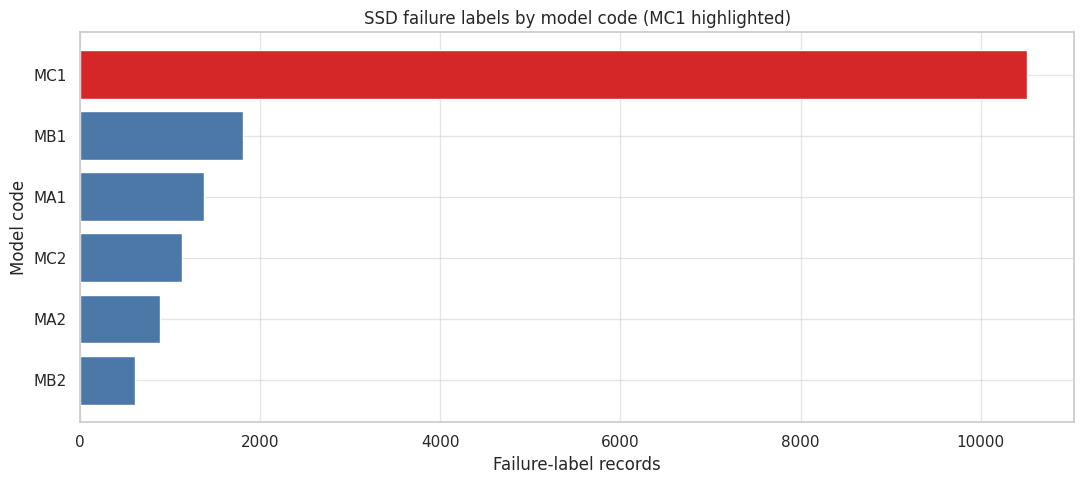

In [18]:
model_plot = model_distribution.head(30).sort_values("FAILURE_LABEL_COUNT")
colors = [
    "#d62728" if str(model).upper() == "MC1" else "#4c78a8"
    for model in model_plot["MODEL_CODE"]
]
_, axis = plt.subplots(figsize=(11, max(5, 0.32 * len(model_plot))))
axis.barh(
    model_plot["MODEL_CODE"].astype(str),
    model_plot["FAILURE_LABEL_COUNT"].astype(float),
    color=colors,
)
axis.set_title("SSD failure labels by model code (MC1 highlighted)")
axis.set_xlabel("Failure-label records")
axis.set_ylabel("Model code")
plt.tight_layout()
plt.show()


### 4.4 Failure timeline table and graph

In [20]:
failure_timeline = aggregate_to_pandas(f'''
    SELECT FAILURE_DATE, COUNT(*) AS FAILURE_LABEL_COUNT
    FROM {LABEL_TABLE}
    GROUP BY FAILURE_DATE
    ORDER BY FAILURE_DATE
''')
failure_timeline



,FAILURE_DATE,FAILURE_LABEL_COUNT
0,2018-01-02,2
1,2018-01-03,4
2,2018-01-04,5
3,2018-01-05,4
4,2018-01-06,3
...,...,...
721,2019-12-27,22
722,2019-12-28,14
723,2019-12-29,20
724,2019-12-30,16


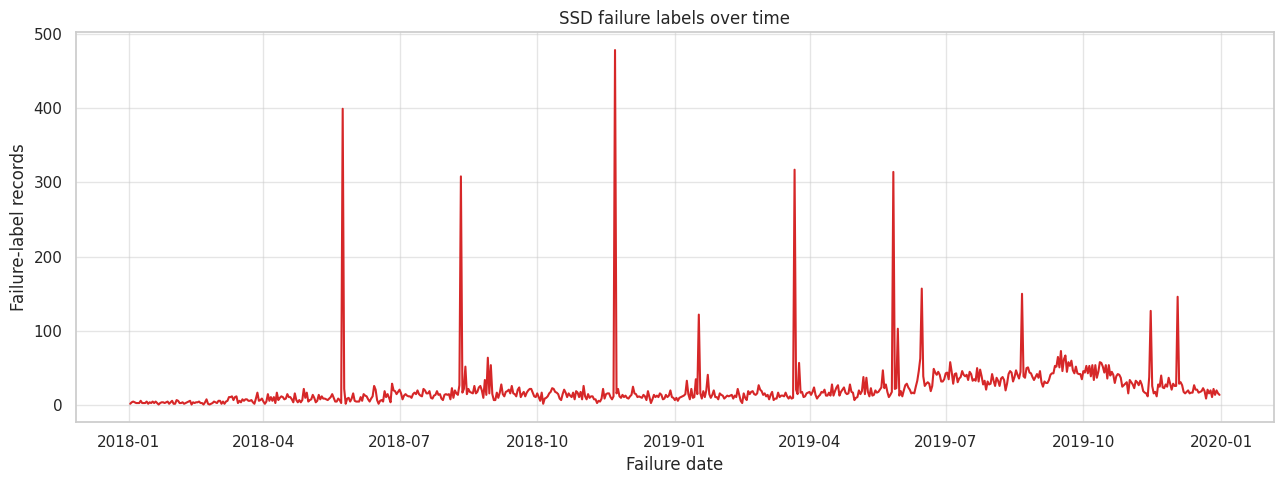

In [21]:
_, axis = plt.subplots(figsize=(13, 5))
axis.plot(
    pd.to_datetime(failure_timeline["FAILURE_DATE"]),
    failure_timeline["FAILURE_LABEL_COUNT"].astype(float),
    color="#d62728",
)
axis.set_title("SSD failure labels over time")
axis.set_xlabel("Failure date")
axis.set_ylabel("Failure-label records")
plt.tight_layout()
plt.show()


## 5. Session cleanup

In [23]:
spark.stop()

26/09/29 20:08:45 WARN SparkConnectorContext$: Finish cancelling all queries for local-1790712111559
